Initialization

In [3]:
from google.colab import drive
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
import sys

drive.mount("/content/drive")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load training data
x_train = torch.from_numpy(np.load("/content/drive/MyDrive/ASVSpoof/Train/ASV_train_LA_x.npy")).to(device)
y_train = torch.from_numpy(np.load("/content/drive/MyDrive/ASVSpoof/Train/ASV_train_LA_y.npy")).to(device)

# load development data
x_dev = torch.from_numpy(np.load("/content/drive/MyDrive/ASVSpoof/Dev/ASV_dev_LA_x.npy")).to(device)
y_dev = torch.from_numpy(np.load("/content/drive/MyDrive/ASVSpoof/Dev/ASV_dev_LA_y.npy")).to(device)

# load evaluation data
x_eval = torch.from_numpy(np.load("/content/drive/MyDrive/ASVSpoof/Eval/ASV_evl_LA_x.npy")).to(device)
y_eval = torch.from_numpy(np.load("/content/drive/MyDrive/ASVSpoof/Eval/ASV_evl_LA_y.npy")).to(device)

print(f"Hardware Check: Using {device}")

Mounted at /content/drive
Hardware Check: Using cuda


In [4]:
# cnn model built based off of pytorch neural network class
class ASVCNN(nn.Module):
    def __init__(self):
        super(ASVCNN, self).__init__()
        # low-level feature extraction
        # convolutional layers, specifically 32 feature maps (filters) sliding across the LFCC
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # batch normalization, recenters the 32 feature maps
        self.bn1 = nn.BatchNorm2d(32)

        # high-level feature extraction
        # looks at 32 maps simutaneously and creates another 64 new feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # slides a 2x2 window across the maps, keeping the max value within that window
        # essentially a compression - halved twice
        self.pool = nn.MaxPool2d(2,2)

        # unlike the convolutional layers, these are linear layers which look at the full picture
        # dimension Check: 20x400 -> 10x200 -> 5x100
        # 64 output channels -> 5x100
        # maps to 128 layers
        self.fc1 = nn.Linear(64 * 5 * 100, 128)
        # judges the layers on 2 outputs, spoof or bonafide
        self.fc2 = nn.Linear(128, 2)

    # assembles all the elements
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 5 * 100)
        # thinks about the patterns
        x = F.relu(self.fc1(x))
        # final verdict
        x = self.fc2(x)
        return x

# maps the model to the L4 gpu
model = ASVCNN().to(device)

In [6]:
# run this block to load the already trained model - skip training phase
model_save_path = "/content/drive/MyDrive/ASVSpoof/asv_cnn_model.pth"
model = ASVCNN().to(device)
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()


ASVCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32000, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [7]:
def calculate_eer(labels, scores, title="EER Curve"):
    """
    Calculates the Equal Error Rate and plots the FPR vs FNR.

    Args:
        labels (list/array): Ground truth binary labels (0 for spoof, 1 for bona_fide)
        scores (list/array): Model probability scores for the bona_fide class
        title (str): Title for the visualization plot

    Returns:
        float: The calculated EER value
    """
    # uses statistical engine for sklearn
    # calculates false positive rate (spoof let in) and true pr. (bonafide let in)
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)

    # calculate false neg. rate (bonafide blocked)
    fnr = 1 - tpr

    # calculate EER according to evaluation plan - where the fpr meets the fnr
    eer_index = np.nanargmin(np.absolute((fpr - fnr)))
    eer = fpr[eer_index]

    print(f"--- {title} ---")
    print(f"Equal Error Rate (EER): {eer * 100:.4f}%")

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, label='False Positive Rate (FPR)')
    plt.plot(fnr, label='False Negative Rate (FNR)')
    plt.axvline(x=eer, color='r', linestyle='--', label=f'EER point ({eer*100:.2f}%)')
    plt.title(title)
    plt.xlabel('Threshold Index')
    plt.ylabel('Error Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

    return eer

Training

In [ ]:
# loads LFCC features + protocol (answer key for training)
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
# measures how far off the model was
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

model.train()
# 10 epochs
for epoch in range(10):
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

torch.save(model.state_dict(), "/content/drive/MyDrive/ASVSpoof/asv_cnn_model.pth")

Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.
Epoch 4 complete.
Epoch 5 complete.
Epoch 6 complete.
Epoch 7 complete.
Epoch 8 complete.
Epoch 9 complete.
Epoch 10 complete.


Development

Inference complete. Scores collected.
--- Development Set EER ---
Equal Error Rate (EER): 0.1346%


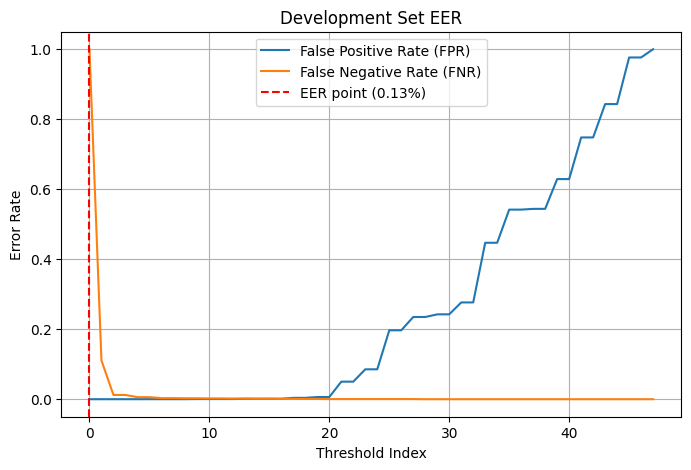

In [ ]:
dev_loader = DataLoader(TensorDataset(x_dev, y_dev), batch_size=32)

model.eval()

current_loader = dev_loader

all_scores = []
all_labels = []

with torch.no_grad():
    for inputs, labels in current_loader:
        outputs = model(inputs)
        # probability of bonafide speech
        probs = torch.softmax(outputs, dim=1)
        all_scores.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

dev_eer = calculate_eer(all_labels, all_scores, title="Development Set EER")

Evaluation

--- Final Evaluation EER ---
Equal Error Rate (EER): 6.7108%


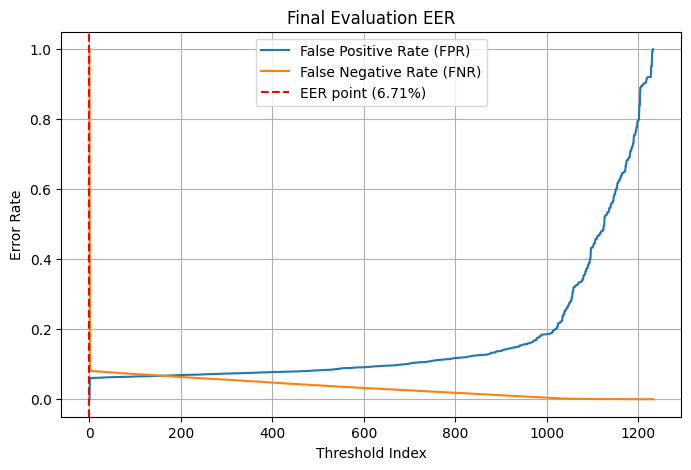

In [8]:
eval_loader = DataLoader(TensorDataset(x_eval, y_eval), batch_size=32)

model.eval()

current_loader = eval_loader

all_scores = []
all_labels = []

with torch.no_grad():
    for inputs, labels in eval_loader:
        outputs = model(inputs)
        # probability of bonafide speech
        probs = torch.softmax(outputs, dim=1)
        all_scores.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

evl_eer = calculate_eer(all_labels, all_scores, title="Final Evaluation EER")

t-DCF Calculation

In [14]:
sys.path.append('/content/drive/MyDrive/ASVSpoof/')

# import t-DCF evaluation implementation provided by ASVspoof
from eval_metrics import (
    compute_eer,
    obtain_asv_error_rates,
    compute_tDCF
)

# costs as given by evaluation plan
Pspoof = 0.05
cost_model = {
    'Pspoof': Pspoof,
    'Ptar': (1 - Pspoof) * 0.99,
    'Pnon': (1 - Pspoof) * 0.01,
    'Cmiss_asv': 1, 'Cfa_asv': 10, 'Cmiss_cm': 1, 'Cfa_cm': 10
}

asv_score_file = '/content/drive/MyDrive/ASVSpoof/Eval/ASVspoof2019.LA.asv.eval.gi.trl.scores.txt'

# load asv data
asv_data = np.genfromtxt(asv_score_file, dtype=str)
asv_keys = asv_data[:, 1]
asv_scores = asv_data[:, 2].astype(float)

tar_asv = asv_scores[asv_keys == 'target']
non_asv = asv_scores[asv_keys == 'nontarget']
spoof_asv = asv_scores[asv_keys == 'spoof']

# align scores from CM result
bona_cm = np.array(all_scores)[np.array(all_labels) == 1]
spoof_cm = np.array(all_scores)[np.array(all_labels) == 0]

# evaluate
eer_asv, asv_threshold = compute_eer(tar_asv, non_asv)
Pfa_asv, Pmiss_asv, Pmiss_spoof_asv = obtain_asv_error_rates(tar_asv, non_asv, spoof_asv, asv_threshold)


tDCF_curve, CM_thresholds = compute_tDCF(
    bona_cm,
    spoof_cm,
    Pfa_asv,
    Pmiss_asv,
    Pmiss_spoof_asv,
    cost_model,
    True
)

min_tDCF = np.min(tDCF_curve)

print(f"\n--- Final Result ---")
print(f"Minimum t-DCF: {min_tDCF:.5f}")

t-DCF evaluation from [Nbona=7355, Nspoof=63882] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.40595 x Pmiss_cm(s) + Pfa_cm(s)


--- Final Result ---
Minimum t-DCF: 0.16016
